In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [4]:


df = pd.read_csv(
    r"C:\Users\M.Durga Prasad\OneDrive\Desktop\Customer_Churn_Prediction\data\processed\customer_churn_cleaned.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df['churn_encoded'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [7]:
X = df.drop(columns = ['customerID', 'Churn', 'churn_encoded'])
y = df['churn_encoded']

In [9]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [10]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
encoder = OneHotEncoder(handle_unknown='ignore', drop='first')

In [33]:
preprocessor = ColumnTransformer(transformers=[('cat', encoder, categorical_cols), ('num', StandardScaler(), numerical_cols)])

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [35]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 30)
(1409, 30)


In [36]:
# logisticRegression
model = LogisticRegression(max_iter=2000)

In [37]:
model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=2000)

In [38]:
y_pre = model.predict(X_test_processed)
print(y_pre[:10])

[0 1 0 0 0 1 0 0 0 0]


In [39]:
print('Actual:', y_test.values[:10])
print('Predicted', y_pre[:10])

Actual: [0 0 0 0 0 0 0 0 0 1]
Predicted [0 1 0 0 0 1 0 0 0 0]


In [41]:
# accuracy score
accuracy = accuracy_score(y_test, y_pre)
print(accuracy)

0.8069552874378992


In [43]:
print(classification_report(y_test, y_pre))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [45]:
cm = confusion_matrix(y_test, y_pre)
print(cm)

[[927 108]
 [164 210]]


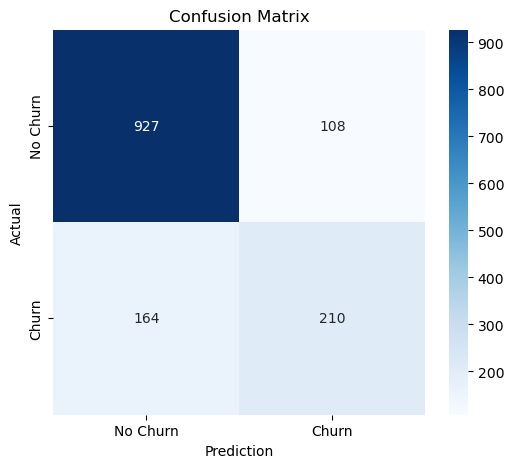

In [49]:
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot = True , fmt ='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], ytickslabels=['No Churn', 'Churn'])

plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [61]:
y_prob = model.predict_proba(X_test_processed)[:, 1]
print(y_prob[:10])
print("y_test shape:", y_test.shape)
print("y_prob shape:", y_prob.shape)

[0.0458386  0.68375823 0.06007238 0.39936455 0.02161438 0.60226845
 0.44714269 0.12890608 0.00289668 0.39605096]
y_test shape: (1409,)
y_prob shape: (1409,)


In [62]:
print('y_test shape', y_test.shape)
print('Prob shape', y_prob.shape)
print('Unique y_prob', y_test.unique())
print('first 10', y_prob[:10])

y_test shape (1409,)
Prob shape (1409,)
Unique y_prob [0 1]
first 10 [0.0458386  0.68375823 0.06007238 0.39936455 0.02161438 0.60226845
 0.44714269 0.12890608 0.00289668 0.39605096]


In [65]:
roc_auc = roc_auc_score(y_test, y_prob)
print('ROC-AUC:', roc_auc)

ROC-AUC: 0.8421710713270816


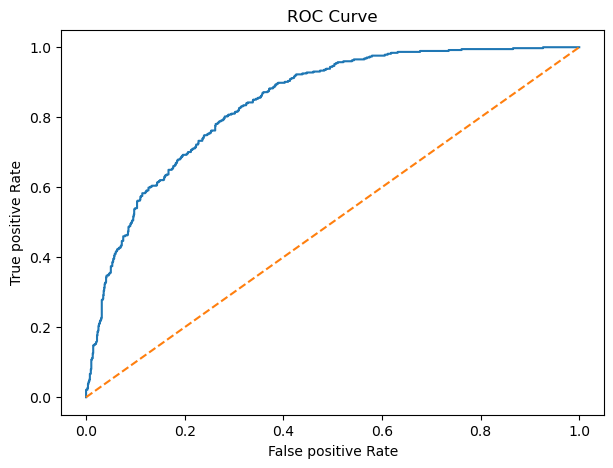

In [68]:
# ROC CURVE
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC= {roc_auc:.2f})')
plt.plot([0,1],[0,1], linestyle='--', label = 'Random Guess')
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.title('ROC Curve')
plt.show()